**Phase 1: One-Shot Learning & Baseline Comparison**
* Implement Bandits and Baseline ML models.
* Perform baseline comparison using Linear Regression, Logistic Regression, and Decision Trees.


**Phase 2: Step-wise Training**
* Implement Active Learning (AL) and Bandits (if possible).
* Generate plots based on the total number of fraud rules specifically for the AL component.


**Phase 3: Active Learning Implementation & Optimization**
* Implement XGBoost and Bandit-based Active Learning using the following strategies: Uncertainty, Cost-weighted, Expected cost reduction, and Diversity.
* If default loss functions are ineffective, implement and test custom loss functions.


**Phase 4: Validation & Visualization**
* Generate decreasing plots for financial costs and increasing plots for recall.
* Include validation plots within the Active Learning section.
* Evaluate data quality: If the Bandit implementation yields proper F1 score plots, the generated data is considered sufficient.

## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!apt-get install git
!git clone https://github.com/Nikshay-Jain/DDP.git /content/drive/MyDrive/

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.15).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
fatal: destination path '/content/drive/MyDrive' already exists and is not an empty directory.


In [3]:
import zipfile, os, shutil
import pandas as pd

zip_path = "/content/drive/MyDrive/DDP/data_5L_new.zip"

extract_dir = "/content/extracted_zip"
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

csv_file = None
for file in os.listdir(extract_dir):
    if file.endswith(".csv"):
        csv_file = os.path.join(extract_dir, file)
        break
if csv_file is None:
    raise FileNotFoundError("No CSV file found inside the ZIP.")

df = pd.read_csv(csv_file)
shutil.rmtree(extract_dir)
print("CSV loaded successfully!")

CSV loaded successfully!


In [5]:
df

,policy_no,policy_product,cust_occupation,tier,tier_premium_amt,occupants_count,paying_guest_no,business_use,unoccupied_days,unoccupied_reason,...,fire_safety_systems,security_systems,crime_rate,urban_rural,no_of_claims_5yr,premium_payment_behaviour,property_market_value,short_term_letting,fraud_probability,fraud_label
0,100000,Combined,skilled_worker,1,166.58,4,0,N,0,NaN,...,0,0,3,urban,0,74,880000,0,0.073655,0
1,100001,Combined,skilled_worker,2,342.37,2,0,N,0,NaN,...,1,1,1,rural,0,82,890000,0,0.066178,0
2,100002,Buildings,skilled_worker,2,325.97,1,0,N,30,NaN,...,0,0,3,urban,0,83,320000,0,0.087979,0
3,100003,Landlord,retired,1,160.16,6,0,N,0,NaN,...,0,1,5,urban,0,86,390000,0,0.062205,0
4,100004,Combined,professional,1,206.89,2,0,N,0,NaN,...,1,1,2,rural,0,71,590000,1,0.089477,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,599995,Standard,white_collar,2,310.44,4,0,N,0,NaN,...,1,1,5,urban,0,84,610000,0,0.079920,0
499996,599996,Combined,retired,2,279.42,4,0,N,30,relocation,...,1,0,3,urban,2,92,300000,0,0.128952,0
499997,599997,Landlord,professional,2,336.84,4,0,N,0,NaN,...,0,1,1,urban,0,87,1060000,0,0.063849,0
499998,599998,Standard,white_collar,1,163.38,3,0,N,0,NaN,...,1,1,2,urban,1,76,390000,0,0.111040,0


## Baseline evaluation

Shapes (train/val/test): (14000, 59) (3000, 59) (3000, 59)
Fraud positives (train/val/test): 704 151 151
sum_insured stats (train): min,median,mean,max: 100000 350000.0 383696.4285714286 850000
Training Logistic Regression
Training Decision Tree
Training Random Forest
Training XGBoost
              Model  Total Cost (£)  FN Cost (£)  FP Cost (£)  FN Count  FP Count  TP   TN  Precision   Recall       F1  ROC AUC  Avg Cost/Sample (£)
      Decision Tree        457200.0     450000.0       7200.0         1        72 150 2777   0.675676 0.993377 0.804290 0.993376           152.400000
      Random Forest        893000.0     630000.0     263000.0         2      2630 149  219   0.053616 0.986755 0.101706 0.967448           297.666667
Logistic Regression       1084300.0    1080000.0       4300.0         2        43 149 2806   0.776042 0.986755 0.868805 0.997810           361.433333
            XGBoost       2076900.0    2070000.0       6900.0         4        69 147 2780   0.680556 0.973510 0.8

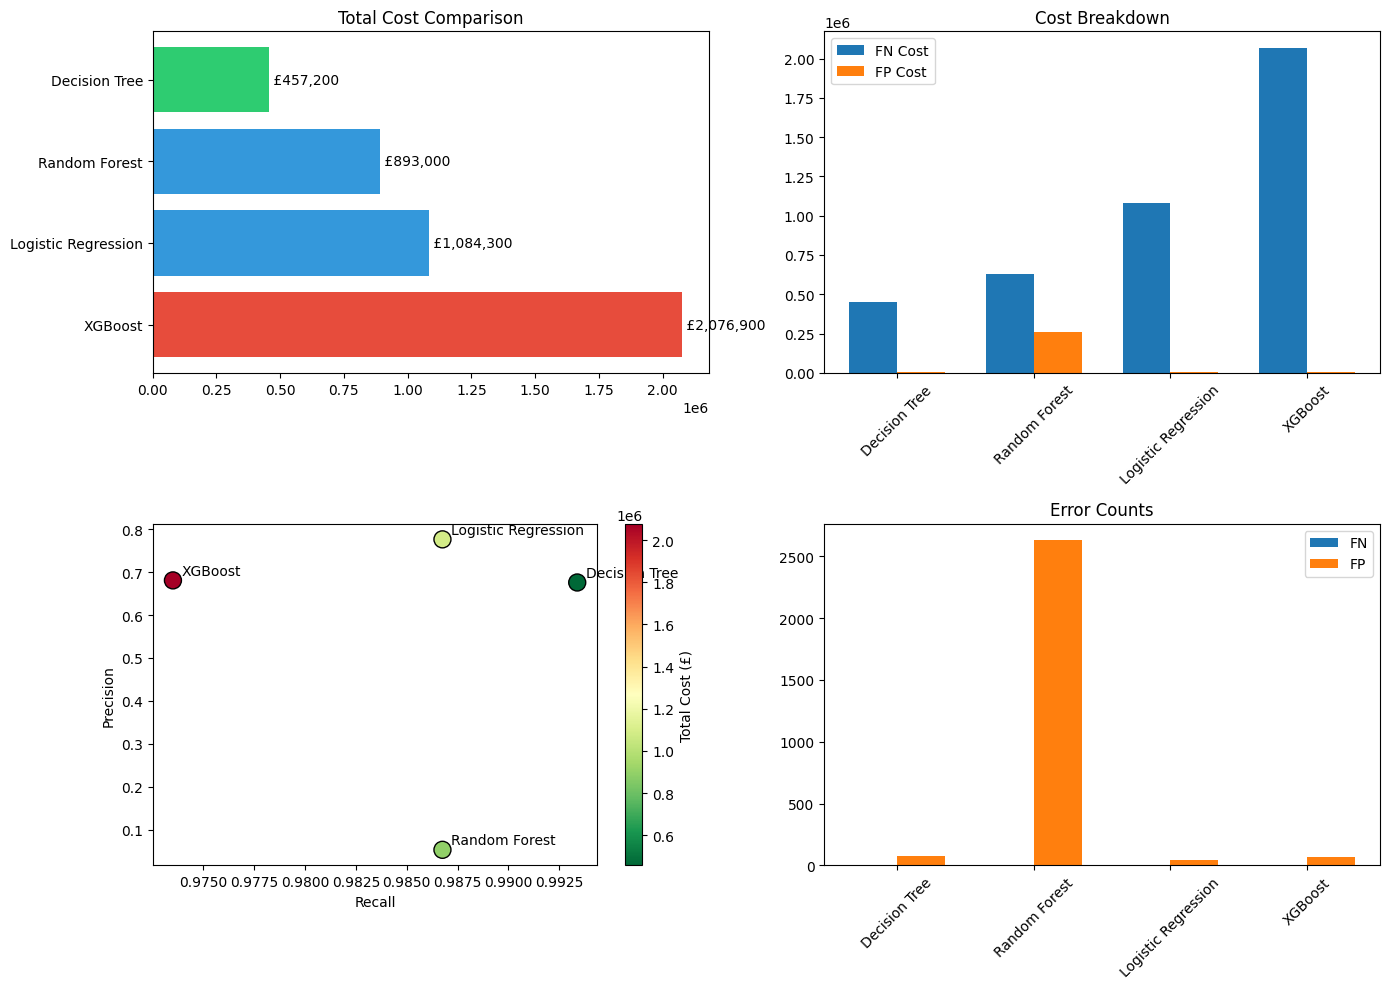

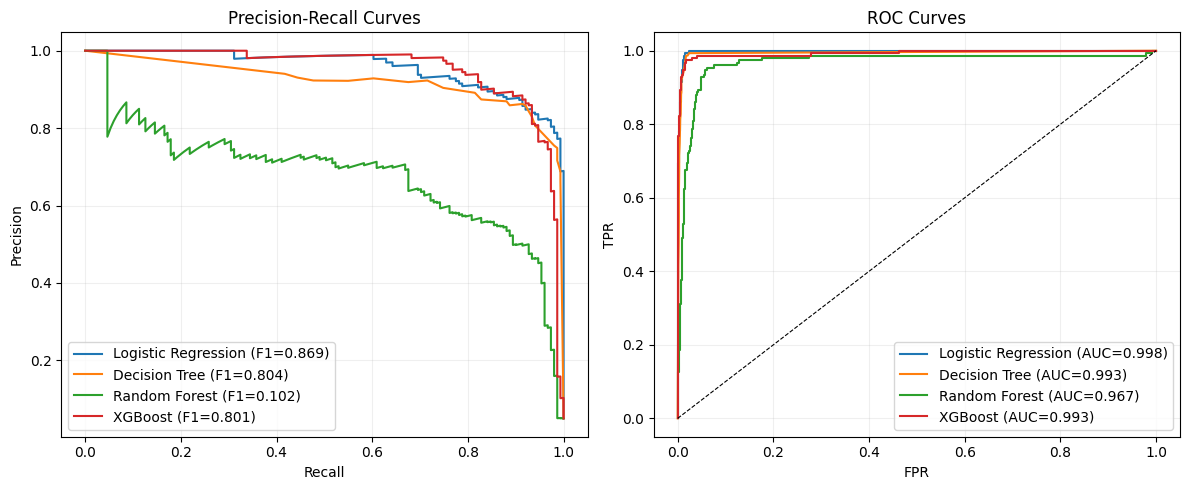

In [18]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, precision_recall_curve, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)


# -------------------------
# Cost helpers
# -------------------------
def calculate_costs(sum_insured, y_true, y_pred):
    s = np.asarray(sum_insured, dtype=float)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    costs = np.zeros(len(y_true), dtype=float)
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    costs[fn_mask] = s[fn_mask] * 0.90
    costs[fp_mask] = 100.0
    return costs


def evaluate_cost_sensitive(y_true, y_pred, sum_insured, y_score=None):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    try:
        rocauc = float(roc_auc_score(y_true, y_score if y_score is not None else y_pred))
    except Exception:
        rocauc = np.nan
    costs = calculate_costs(sum_insured, y_true, y_pred)
    fn_mask = (np.asarray(y_true) == 1) & (np.asarray(y_pred) == 0)
    fp_mask = (np.asarray(y_true) == 0) & (np.asarray(y_pred) == 1)
    return {
        'total_cost': float(costs.sum()),
        'fn_cost': float(costs[fn_mask].sum()),
        'fp_cost': float(costs[fp_mask].sum()),
        'fn_count': int(fn_mask.sum()),
        'fp_count': int(fp_mask.sum()),
        'tp': int(((np.asarray(y_true) == 1) & (np.asarray(y_pred) == 1)).sum()),
        'tn': int(((np.asarray(y_true) == 0) & (np.asarray(y_pred) == 0)).sum()),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'roc_auc': rocauc,
        'avg_cost_per_sample': float(costs.sum() / len(y_true))
    }


# -------------------------
# Stratified sampling utility
# -------------------------
def stratified_sample(df, label_col='fraud_label', n=20000, random_state=42):
    counts = df[label_col].value_counts().sort_index()
    total = counts.sum()
    if n >= total:
        return df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    proportions = counts / total
    raw_alloc = proportions * n
    floor_alloc = np.floor(raw_alloc).astype(int)
    remainder = raw_alloc - floor_alloc
    allocated = floor_alloc.copy()
    remaining = int(n - floor_alloc.sum())
    if remaining > 0:
        idx_sort = np.argsort(-remainder.values)
        for i in range(remaining):
            allocated[idx_sort[i]] += 1
    parts = []
    for label, k in zip(counts.index, allocated):
        g = df[df[label_col] == label]
        parts.append(g.sample(n=min(k, len(g)), random_state=random_state) if len(g) > 0 else g)
    sampled = pd.concat(parts, ignore_index=True).sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    return sampled

# -------------------------
# feature preparation (robust)
# -------------------------
def prepare_data(df, label_col='fraud_label', sum_col='sum_insured'):
    """Prepare features with robust fallback."""
    feature_template = [
        'tier', 'tier_premium_amt', 'occupants_count', 'paying_guest_no',
        'unoccupied_days', 'sum_insured', 'premium_with_tax',
        'risk_premium_with_credit_score', 'risk_premium_without_credit_score',
        'additional_coverage_amount', 'tier_limit_value', 'item_limit_value',
        'main_part_premium', 'accidental_damage_premium', 'outbuildings_premium',
        'APR_FLAG', 'previous_insurance_buildings', 'previous_insurance_cne',
        'property_eligibility', 'contents_claim_counts', 'building_claim_count',
        'flood_risk', 'storm_risk', 'other_natural_calamities_risk',
        'property_age', 'no_of_rooms', 'plumbing_elec_age',
        'smart_home', 'fire_safety_systems', 'security_systems',
        'crime_rate', 'no_of_claims_5yr', 'premium_payment_behaviour',
        'property_market_value', 'short_term_letting'
    ]
    categorical_template = ['cust_occupation', 'owner_details', 'property_type',
                           'construction_material', 'roof_material', 'urban_rural', 'policy_product']

    feature_cols = [c for c in feature_template if c in df.columns and c != label_col]
    categorical_cols = [c for c in categorical_template if c in df.columns]

    if not feature_cols:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        feature_cols = [c for c in numeric_cols if c not in [label_col, sum_col]]

    df_enc = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    all_features = [c for c in df_enc.columns if (c in feature_cols) or any(cat in c for cat in categorical_cols)]

    if not all_features:
        all_features = [c for c in df_enc.select_dtypes(include=[np.number]).columns if c not in [label_col, sum_col]]

    X = df_enc[all_features].fillna(0).values
    y = df_enc[label_col].values
    sum_insured = df_enc[sum_col].values if sum_col in df_enc.columns else np.zeros(len(df_enc))

    return X, y, sum_insured, all_features

# -------------------------
# Cost-sensitive classifier wrapper (uses sample_weight and threshold tuning on validation)
# -------------------------
class CostSensitiveClassifier:
    def __init__(self, base_clf):
        self.clf = base_clf
        self.opt_threshold = 0.5

    def fit(self, X, y, sum_insured=None, X_val=None, y_val=None, sum_val=None, **fit_kwargs):
        # compute sample weights encoding cost: weight = y*(0.9*w) + (1-y)*100
        sample_weight = None
        if sum_insured is not None:
            s = np.asarray(sum_insured, dtype=float)
            sample_weight = (y * (0.9 * s)) + ((1 - y) * 100.0)
        try:
            if sample_weight is not None:
                self.clf.fit(X, y, sample_weight=sample_weight, **fit_kwargs)
            else:
                self.clf.fit(X, y, **fit_kwargs)
        except TypeError:
            # fallback if classifier doesn't support sample_weight argument
            self.clf.fit(X, y, **fit_kwargs)

        # threshold tuning on provided validation set (preferred)
        if X_val is not None and y_val is not None and sum_val is not None and hasattr(self.clf, "predict_proba"):
            proba = self.clf.predict_proba(X_val)[:, 1]
            thresholds = np.linspace(0.01, 0.99, 99)
            best_cost = np.inf
            best_t = 0.5
            for t in thresholds:
                y_pred = (proba >= t).astype(int)
                c = calculate_costs(sum_val, y_val, y_pred).sum()
                if c < best_cost:
                    best_cost = c
                    best_t = t
            self.opt_threshold = float(best_t)
        else:
            # fallback: tune on training set if validation not provided
            if sum_insured is not None and hasattr(self.clf, "predict_proba"):
                proba = self.clf.predict_proba(X)[:, 1]
                thresholds = np.linspace(0.01, 0.99, 99)
                best_cost = np.inf
                best_t = 0.5
                for t in thresholds:
                    y_pred = (proba >= t).astype(int)
                    c = calculate_costs(sum_insured, y, y_pred).sum()
                    if c < best_cost:
                        best_cost = c
                        best_t = t
                self.opt_threshold = float(best_t)
        return self

    def predict(self, X):
        if hasattr(self.clf, "predict_proba"):
            proba = self.clf.predict_proba(X)[:, 1]
            return (proba >= self.opt_threshold).astype(int)
        return self.clf.predict(X)

    def predict_proba(self, X):
        if hasattr(self.clf, "predict_proba"):
            return self.clf.predict_proba(X)
        if hasattr(self.clf, "decision_function"):
            s = self.clf.decision_function(X)
            p = 1 / (1 + np.exp(-s))
            return np.vstack([1 - p, p]).T
        preds = self.clf.predict(X)
        return np.vstack([1 - preds, preds]).T


# -------------------------
# Main compare function for ML baselines
# -------------------------
def compare_models(df, sample_size=20000, label_col='fraud_label', sum_col='sum_insured', random_state=42):
    df_s = stratified_sample(df, label_col=label_col, n=sample_size, random_state=random_state)
    X, y, sum_ins, feature_names = prepare_data(df_s, label_col=label_col, sum_col=sum_col)

    # train/val/test (70/15/15) stratified
    X_train, X_temp, y_train, y_temp, sum_train, sum_temp = train_test_split(
        X, y, sum_ins, test_size=0.30, random_state=random_state, stratify=y
    )
    X_val, X_test, y_val, y_test, sum_val, sum_test = train_test_split(
        X_temp, y_temp, sum_temp, test_size=0.50, random_state=random_state, stratify=y_temp
    )

    print("Shapes (train/val/test):", X_train.shape, X_val.shape, X_test.shape)
    print("Fraud positives (train/val/test):", y_train.sum(), y_val.sum(), y_test.sum())
    print("sum_insured stats (train): min,median,mean,max:",
          np.min(sum_train), np.median(sum_train), np.mean(sum_train), np.max(sum_train))

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)

    results = {}
    probs_store = {}

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, class_weight=None, random_state=random_state),
        'Decision Tree': DecisionTreeClassifier(max_depth=10, min_samples_split=50, min_samples_leaf=20,
                                                class_weight=None, random_state=random_state),
        'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=50,
                                               class_weight=None, random_state=random_state),
        'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                 use_label_encoder=False, eval_metric='logloss', random_state=random_state)
    }

    for name, base_clf in models.items():
        print("Training", name)
        cs = CostSensitiveClassifier(base_clf).fit(X_train_s, y_train, sum_insured=sum_train,
                                                   X_val=X_val_s, y_val=y_val, sum_val=sum_val)
        y_pred = cs.predict(X_test_s)
        y_proba = cs.predict_proba(X_test_s)[:, 1]
        r = evaluate_cost_sensitive(y_test, y_pred, sum_test, y_score=y_proba)
        r['proba'] = y_proba
        results[name] = r
        probs_store[name] = (y_test, y_proba)

    # explicit DataFrame construction
    rows = []
    for m, r in results.items():
        rows.append({
            'Model': m,
            'Total Cost (£)': float(r['total_cost']),
            'FN Cost (£)': float(r['fn_cost']),
            'FP Cost (£)': float(r['fp_cost']),
            'FN Count': int(r['fn_count']),
            'FP Count': int(r['fp_count']),
            'TP': int(r['tp']),
            'TN': int(r['tn']),
            'Precision': float(r['precision']),
            'Recall': float(r['recall']),
            'F1': float(r['f1']),
            'ROC AUC': float(r['roc_auc']) if r['roc_auc'] is not None else np.nan,
            'Avg Cost/Sample (£)': float(r['avg_cost_per_sample'])
        })
    comp = pd.DataFrame(rows).sort_values('Total Cost (£)').reset_index(drop=True)
    print(comp.to_string(index=False))

    # Visualizations (cost+metrics + PR/ROC)
    plt.figure(figsize=(14, 10))
    # total cost
    plt.subplot(2, 2, 1)
    models_list = comp['Model']
    costs = comp['Total Cost (£)']
    colors = ['#2ecc71' if c == costs.min() else '#e74c3c' if c == costs.max() else '#3498db' for c in costs]
    plt.barh(models_list, costs, color=colors)
    plt.gca().invert_yaxis()
    plt.title('Total Cost Comparison')
    for i, v in enumerate(costs): plt.text(v, i, f' £{v:,.0f}', va='center')

    # cost breakdown
    plt.subplot(2, 2, 2)
    x = np.arange(len(models_list)); width = 0.35
    plt.bar(x - width/2, comp['FN Cost (£)'], width, label='FN Cost')
    plt.bar(x + width/2, comp['FP Cost (£)'], width, label='FP Cost')
    plt.xticks(x, models_list, rotation=45)
    plt.legend()
    plt.title('Cost Breakdown')

    # PR scatter
    plt.subplot(2, 2, 3)
    sc = plt.scatter(comp['Recall'], comp['Precision'], s=150, c=comp['Total Cost (£)'], cmap='RdYlGn_r', edgecolors='k')
    for i, m in enumerate(models_list): plt.annotate(m, (comp['Recall'].iloc[i], comp['Precision'].iloc[i]), xytext=(6,4), textcoords='offset points')
    plt.colorbar(sc, label='Total Cost (£)'); plt.xlabel('Recall'); plt.ylabel('Precision')

    # error counts
    plt.subplot(2, 2, 4)
    plt.bar(x - width/2, comp['FN Count'], width, label='FN')
    plt.bar(x + width/2, comp['FP Count'], width, label='FP')
    plt.xticks(x, models_list, rotation=45)
    plt.legend()
    plt.title('Error Counts')

    plt.tight_layout()
    plt.show()

    # PR & ROC curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    for m, (y_t, y_p) in probs_store.items():
        try:
            p, r, _ = precision_recall_curve(y_t, y_p)
            plt.plot(r, p, label=f"{m} (F1={results[m]['f1']:.3f})")
        except Exception:
            continue
    plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall Curves'); plt.legend(); plt.grid(alpha=0.2)

    plt.subplot(1, 2, 2)
    for m, (y_t, y_p) in probs_store.items():
        try:
            fpr, tpr, _ = roc_curve(y_t, y_p)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{m} (AUC={roc_auc:.3f})")
        except Exception:
            continue
    plt.plot([0, 1], [0, 1], 'k--', lw=0.8)
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curves'); plt.legend(); plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    return results, comp

results_ml, comparison_ml = compare_models(df, sample_size=20000)

## RL algos

Shapes (train/val/test): (14000, 39) (3000, 39) (3000, 39)
Fraud positives (train/val/test): 704 151 151
sum_insured stats (train): min,median,mean,max: 100000.0 350000.0 383696.4285714286 850000.0
Training IDCSPA...
Training CSLB...
 Model  Total Cost (£)  FN Cost (£)  FP Cost (£)  FN Count  FP Count  TP   TN  Precision   Recall       F1  ROC AUC  Avg Cost/Sample (£)
IDCSPA         74100.0          0.0      74100.0         0       741 151 2108   0.169283 1.000000 0.289549 0.995560            24.700000
  CSLB      10632500.0   10485000.0     147500.0        31      1475 120 1374   0.075235 0.794702 0.137457 0.953333          3544.166667


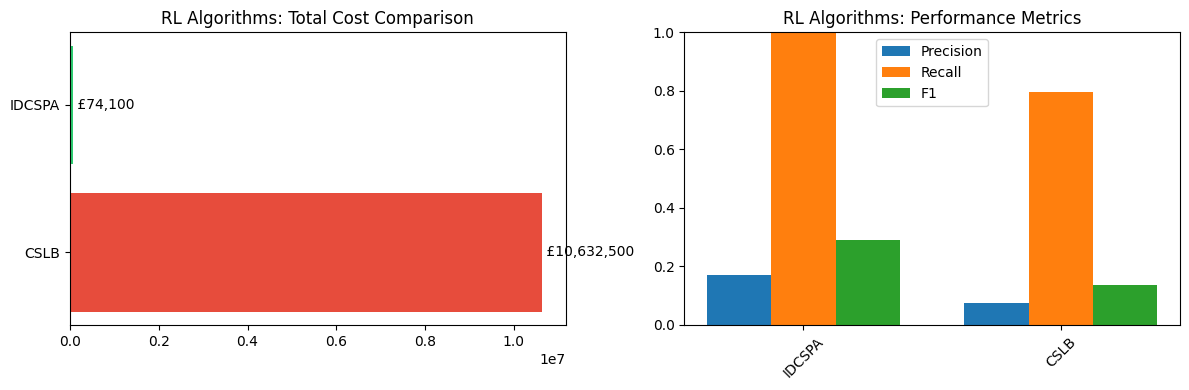

In [24]:
# RL.py (corrected)
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# -------------------------
# Defaults for unified cost model
# -------------------------
FP_COST_DEFAULT = 100.0        # default false-positive cost (can be overridden)
FN_MULTIPLIER_DEFAULT = 0.9    # FN cost = FN_MULTIPLIER * sum_insured

# -------------------------
# Cost helpers (shared convention)
# -------------------------
def calculate_costs(sum_insured, y_true, y_pred, fp_cost=FP_COST_DEFAULT, fn_multiplier=FN_MULTIPLIER_DEFAULT):
    """
    Vectorized cost:
      FN = fn_multiplier * sum_insured
      FP = fp_cost
      TP/TN = 0
    """
    s = np.asarray(sum_insured, dtype=float)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    costs = np.zeros(len(y_true), dtype=float)
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    costs[fn_mask] = s[fn_mask] * float(fn_multiplier)
    costs[fp_mask] = float(fp_cost)
    return costs


def evaluate_cost_sensitive(y_true, y_pred, sum_insured, y_score=None,
                            fp_cost=FP_COST_DEFAULT, fn_multiplier=FN_MULTIPLIER_DEFAULT):
    """
    Returns a dict of cost metrics and classification metrics.
    Uses the unified cost parameters.
    """
    costs = calculate_costs(sum_insured, y_true, y_pred, fp_cost=fp_cost, fn_multiplier=fn_multiplier)
    fn_mask = (np.asarray(y_true) == 1) & (np.asarray(y_pred) == 0)
    fp_mask = (np.asarray(y_true) == 0) & (np.asarray(y_pred) == 1)

    from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    try:
        rocauc = float(roc_auc_score(y_true, y_score if y_score is not None else y_pred))
    except Exception:
        rocauc = np.nan

    return {
        'total_cost': float(costs.sum()),
        'fn_cost': float(costs[fn_mask].sum()),
        'fp_cost': float(costs[fp_mask].sum()),
        'fn_count': int(fn_mask.sum()),
        'fp_count': int(fp_mask.sum()),
        'tp': int(((np.asarray(y_true) == 1) & (np.asarray(y_pred) == 1)).sum()),
        'tn': int(((np.asarray(y_true) == 0) & (np.asarray(y_pred) == 0)).sum()),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'roc_auc': rocauc,
        'avg_cost_per_sample': float(costs.sum() / len(y_true))
    }


# -------------------------
# Stratified sampling utility
# -------------------------
def stratified_sample(df, label_col='fraud_label', n=20000, random_state=42):
    """
    Large-remainder proportional stratified sampling; if n >= len(df) returns shuffled df.
    """
    counts = df[label_col].value_counts().sort_index()
    total = counts.sum()
    if n >= total:
        return df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    proportions = counts / total
    raw_alloc = proportions * n
    floor_alloc = np.floor(raw_alloc).astype(int)
    remainder = raw_alloc - floor_alloc
    allocated = floor_alloc.copy()
    remaining = int(n - floor_alloc.sum())
    if remaining > 0:
        idx_sort = np.argsort(-remainder.values)
        for i in range(remaining):
            allocated[idx_sort[i]] += 1

    parts = []
    for label, k in zip(counts.index, allocated):
        g = df[df[label_col] == label]
        parts.append(g.sample(n=min(k, len(g)), random_state=random_state) if len(g) > 0 else g)
    sampled = pd.concat(parts, ignore_index=True).sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    return sampled


# -------------------------
# IDCSPA: Instance-Dependent Cost-Sensitive Passive-Aggressive
# -------------------------
class IDCSPA:
    def __init__(self, C=1.0, fp_cost=FP_COST_DEFAULT, fn_multiplier=FN_MULTIPLIER_DEFAULT):
        self.C = float(C)
        self.theta = None
        self.fp_cost = float(fp_cost)
        self.fn_multiplier = float(fn_multiplier)

    def fit(self, X, y, sum_insured, epochs=3):
        """
        Online updates. y in {0,1} internally; uses unified cost model.
        """
        n, d = X.shape
        self.theta = np.zeros(d, dtype=float)
        y_signed = (2 * np.asarray(y).astype(int)) - 1

        for epoch in range(epochs):
            idx = np.random.permutation(n)
            for i in idx:
                x_i = X[i]
                y_i = y_signed[i]
                w_i = float(sum_insured[i])

                y_pred_raw = np.sign(self.theta.dot(x_i))
                if y_pred_raw == 0:
                    y_pred_raw = -1

                # use unified costs
                if y_pred_raw == -1 and y_i == 1:   # FN
                    loss = w_i * self.fn_multiplier
                elif y_pred_raw == 1 and y_i == -1:  # FP
                    loss = self.fp_cost
                else:
                    loss = 0.0

                if loss > 0:
                    numerator = (y_pred_raw - y_i) * (self.theta.dot(x_i)) + np.sqrt(loss)
                    denom = np.linalg.norm((y_pred_raw - y_i) * x_i) ** 2
                    if denom <= 0:
                        continue
                    tau = min(self.C, max(0.0, numerator / denom))
                    self.theta += tau * (y_i - y_pred_raw) * x_i
        return self

    def predict(self, X):
        preds = np.sign(X.dot(self.theta))
        preds[preds == 0] = -1
        return ((preds + 1) / 2).astype(int)

    def decision_function(self, X):
        return X.dot(self.theta)


# -------------------------
# CSLB: Cost-Sensitive Logistic Bandit (cost-aligned surrogate objective)
# -------------------------
class CSLB:
    def __init__(self, alpha=1.0, lam=1e-3, maxiter=200,
                 fp_cost=FP_COST_DEFAULT, fn_multiplier=FN_MULTIPLIER_DEFAULT):
        """
        alpha: prior scaling for initial covariance
        lam: L2 regularization
        maxiter: L-BFGS max iterations
        fp_cost, fn_multiplier: unified cost parameters
        """
        self.alpha = float(alpha)
        self.lam = float(lam)
        self.maxiter = int(maxiter)
        self.theta_mean = None
        self.theta_cov = None
        self.fp_cost = float(fp_cost)
        self.fn_multiplier = float(fn_multiplier)

    def _sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def _compute_threshold(self, sum_insured):
        """
        Per-instance decision threshold consistent with evaluation:
          h(w) = FP / (FP + FN)
        """
        w = float(sum_insured)
        FP = float(self.fp_cost)
        FN = float(self.fn_multiplier) * w
        denom = FP + FN
        if denom <= 0:
            return 0.5
        return float(np.clip(FP / denom, 0.0, 1.0))

    def _obj_and_grad(self, theta, X, y, sum_ins_scaled):
        """
        Minimize average expected cost of a stochastic policy that flags with prob p=sigma(X theta).
        Per-sample expected cost:
            E[cost] = y*(1-p)*FN + (1-y)*p*FP
        This is differentiable and aligns training with evaluation.
        Returns (obj, grad)
        """
        n = X.shape[0]
        z = X.dot(theta)
        p = self._sigmoid(z)  # (n,)

        # recover true FN and FP per (scaled) sums; note we used scaled sums for optimization
        # the actual FN scale will be accounted by scaling factor (handled when building sum_ins_scaled)
        FN_vec = self.fn_multiplier * sum_ins_scaled  # per-sample FN (scaled)
        FP = self.fp_cost  # scalar

        # average expected cost
        cost_vec = y * (1 - p) * FN_vec + (1 - y) * p * FP
        obj = float(cost_vec.mean() + 0.5 * self.lam * np.dot(theta, theta))

        # gradient: for sample i, d/dtheta = p*(1-p)*x_i * ( - y_i * FN_i + (1 - y_i) * FP )
        coeff = ( - y * FN_vec + (1 - y) * FP ) * (p * (1 - p))  # (n,)
        grad = (X.T.dot(coeff) / max(1, n)) + self.lam * theta

        return obj, grad

    def fit(self, X, y, sum_insured):
        """
        Fit by optimizing the differentiable expected-cost surrogate.
        We scale sum_insured internally for numeric stability.
        """
        X = np.asarray(X)
        y = np.asarray(y).astype(int)
        n, d = X.shape

        if self.theta_mean is None:
            self.theta_mean = np.zeros(d, dtype=float)
            self.theta_cov = np.eye(d) * self.alpha

        # scale sums for optimization
        scale = (np.mean(sum_insured) + 1e-9)
        sum_scaled = np.asarray(sum_insured, dtype=float) / scale

        def fun(theta):
            return self._obj_and_grad(theta, X, y, sum_scaled)

        res = minimize(fun, self.theta_mean, method='L-BFGS-B', jac=True,
                       options={'maxiter': self.maxiter, 'disp': False})

        # accept best found solution
        self.theta_mean = res.x

        # Hessian (Laplace approx) compute with regularization
        eps = 1e-6
        z = X.dot(self.theta_mean)
        p = self._sigmoid(z)
        W = p * (1 - p)
        X_weighted = X * W[:, None]
        H = (X.T.dot(X_weighted) / max(1, n)) + (eps + self.lam) * np.eye(d)

        try:
            self.theta_cov = np.linalg.inv(H)
        except np.linalg.LinAlgError:
            self.theta_cov = np.linalg.pinv(H)

        return self

    def predict(self, X, sum_insured):
        """
        Thompson sampling: sample one theta from posterior, then apply per-instance threshold h(w).
        """
        if self.theta_mean is None:
            raise ValueError("CSLB not fitted")

        try:
            theta_sample = np.random.multivariate_normal(self.theta_mean, self.theta_cov)
        except Exception:
            theta_sample = self.theta_mean.copy()

        p = self._sigmoid(X.dot(theta_sample))
        thresholds = np.array([self._compute_threshold(w) for w in np.atleast_1d(sum_insured)])
        return (p >= thresholds).astype(int)

    def predict_proba(self, X):
        if self.theta_mean is None:
            raise ValueError("CSLB not fitted")
        probs = self._sigmoid(X.dot(self.theta_mean))
        return np.vstack([1 - probs, probs]).T


# -------------------------
# Compare RL algorithms (IDCSPA vs CSLB) - now cost-aligned
# -------------------------
def compare_rl_algorithms(df, sample_size=20000, label_col='fraud_label', sum_col='sum_insured',
                          random_state=42, fp_cost=FP_COST_DEFAULT, fn_multiplier=FN_MULTIPLIER_DEFAULT):
    """
    Stratified sample -> stratified train/val/test (70/15/15) -> train IDCSPA and CSLB -> evaluate on test.
    fp_cost and fn_multiplier override defaults and are passed through to models & evaluation.
    """
    # stratified sample
    df_s = stratified_sample(df, label_col=label_col, n=sample_size, random_state=random_state)

    # numeric feature selection (use numeric columns)
    numeric_cols = df_s.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in [label_col, sum_col]]
    if len(feature_cols) == 0:
        raise ValueError("No numeric features found in df sample. Provide numeric feature columns.")

    X_all = df_s[feature_cols].fillna(0).values
    y_all = df_s[label_col].values.astype(int)
    sum_all = df_s[sum_col].values.astype(float) if sum_col in df_s.columns else np.ones(len(df_s)) * 1000.0

    # train/val/test stratified (70/15/15)
    X_train, X_temp, y_train, y_temp, sum_train, sum_temp = train_test_split(
        X_all, y_all, sum_all, test_size=0.30, random_state=random_state, stratify=y_all
    )
    X_val, X_test, y_val, y_test, sum_val, sum_test = train_test_split(
        X_temp, y_temp, sum_temp, test_size=0.50, random_state=random_state, stratify=y_temp
    )

    # diagnostics
    print("Shapes (train/val/test):", X_train.shape, X_val.shape, X_test.shape)
    print("Fraud positives (train/val/test):", y_train.sum(), y_val.sum(), y_test.sum())
    print("sum_insured stats (train): min,median,mean,max:",
          np.min(sum_train), np.median(sum_train), np.mean(sum_train), np.max(sum_train))

    # standardize features
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)

    results = {}
    probs_store = {}

    # 1) IDCSPA (use unified cost)
    print("Training IDCSPA...")
    idcspa = IDCSPA(C=1.0, fp_cost=fp_cost, fn_multiplier=fn_multiplier).fit(X_train_s, y_train, sum_train, epochs=3)
    y_pred_idcspa = idcspa.predict(X_test_s)
    probs_idcspa = idcspa.decision_function(X_test_s)
    probs_idcspa = 1 / (1 + np.exp(-probs_idcspa))
    results['IDCSPA'] = evaluate_cost_sensitive(y_test, y_pred_idcspa, sum_test, y_score=probs_idcspa,
                                               fp_cost=fp_cost, fn_multiplier=fn_multiplier)
    results['IDCSPA']['proba'] = probs_idcspa
    probs_store['IDCSPA'] = (y_test, probs_idcspa)

    # 2) CSLB (surrogate expected-cost objective + Thompson sampling + unified cost)
    print("Training CSLB...")
    cslb = CSLB(alpha=1.0, lam=1e-3, maxiter=200, fp_cost=fp_cost, fn_multiplier=fn_multiplier).fit(
        X_train_s, y_train, sum_train)
    y_pred_cslb = cslb.predict(X_test_s, sum_test)
    probs_cslb = cslb.predict_proba(X_test_s)[:, 1]
    results['CSLB'] = evaluate_cost_sensitive(y_test, y_pred_cslb, sum_test, y_score=probs_cslb,
                                              fp_cost=fp_cost, fn_multiplier=fn_multiplier)
    results['CSLB']['proba'] = probs_cslb
    probs_store['CSLB'] = (y_test, probs_cslb)

    # build comparison DataFrame explicitly
    rows = []
    for m, r in results.items():
        rows.append({
            'Model': m,
            'Total Cost (£)': float(r['total_cost']),
            'FN Cost (£)': float(r['fn_cost']),
            'FP Cost (£)': float(r['fp_cost']),
            'FN Count': int(r['fn_count']),
            'FP Count': int(r['fp_count']),
            'TP': int(r['tp']),
            'TN': int(r['tn']),
            'Precision': float(r['precision']),
            'Recall': float(r['recall']),
            'F1': float(r['f1']),
            'ROC AUC': float(r['roc_auc']) if r['roc_auc'] is not None else np.nan,
            'Avg Cost/Sample (£)': float(r['avg_cost_per_sample'])
        })
    comp = pd.DataFrame(rows).sort_values('Total Cost (£)').reset_index(drop=True)
    print(comp.to_string(index=False))

    # quick plots (cost bar and metrics)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    models = comp['Model']
    costs = comp['Total Cost (£)']
    colors = ['#2ecc71' if c == costs.min() else '#e74c3c' if c == costs.max() else '#3498db' for c in costs]
    plt.barh(models, costs, color=colors)
    plt.gca().invert_yaxis()
    plt.title('RL Algorithms: Total Cost Comparison')
    for i, v in enumerate(costs): plt.text(v, i, f' £{v:,.0f}', va='center')

    plt.subplot(1, 2, 2)
    x = np.arange(len(models))
    width = 0.25
    plt.bar(x - width, comp['Precision'], width, label='Precision')
    plt.bar(x, comp['Recall'], width, label='Recall')
    plt.bar(x + width, comp['F1'], width, label='F1')
    plt.xticks(x, models, rotation=45)
    plt.ylim(0, 1)
    plt.legend()
    plt.title('RL Algorithms: Performance Metrics')
    plt.tight_layout()
    plt.show()

    return results, comp

results_rl, comparison_rl = compare_rl_algorithms(df, sample_size=20000)

In [25]:
results_rl

{'IDCSPA': {'total_cost': 74100.0,
  'fn_cost': 0.0,
  'fp_cost': 74100.0,
  'fn_count': 0,
  'fp_count': 741,
  'tp': 151,
  'tn': 2108,
  'precision': 0.16928251121076232,
  'recall': 1.0,
  'f1': 0.28954937679769893,
  'roc_auc': 0.9955601942356909,
  'avg_cost_per_sample': 24.7,
  'proba': array([2.05920946e-02, 1.06974157e-02, 9.38669310e-01, ...,
         4.22845754e-03, 2.14916270e-04, 6.67755417e-02])},
 'CSLB': {'total_cost': 10632500.0,
  'fn_cost': 10485000.0,
  'fp_cost': 147500.0,
  'fn_count': 31,
  'fp_count': 1475,
  'tp': 120,
  'tn': 1374,
  'precision': 0.07523510971786834,
  'recall': 0.7947019867549668,
  'f1': 0.13745704467353953,
  'roc_auc': 0.9533332248564037,
  'avg_cost_per_sample': 3544.1666666666665,
  'proba': array([1.06873372e-03, 6.92924670e-04, 9.69958338e-04, ...,
         6.09963183e-04, 3.29360499e-04, 1.00000000e+00])}}

In [26]:
comparison_rl

,Model,Total Cost (£),FN Cost (£),FP Cost (£),FN Count,FP Count,TP,TN,Precision,Recall,F1,ROC AUC,Avg Cost/Sample (£)
0,IDCSPA,74100.0,0.0,74100.0,0,741,151,2108,0.169283,1.000000,0.289549,0.995560,24.700000
1,CSLB,10632500.0,10485000.0,147500.0,31,1475,120,1374,0.075235,0.794702,0.137457,0.953333,3544.166667


In [27]:
# Combined comparison
combined = pd.concat([comparison_ml, comparison_rl]).sort_values('Total Cost (£)')
combined

,Model,Total Cost (£),FN Cost (£),FP Cost (£),FN Count,FP Count,TP,TN,Precision,Recall,F1,ROC AUC,Avg Cost/Sample (£)
0,IDCSPA,74100.0,0.0,74100.0,0,741,151,2108,0.169283,1.000000,0.289549,0.995560,24.700000
0,Decision Tree,457200.0,450000.0,7200.0,1,72,150,2777,0.675676,0.993377,0.804290,0.993376,152.400000
1,Random Forest,893000.0,630000.0,263000.0,2,2630,149,219,0.053616,0.986755,0.101706,0.967448,297.666667
2,Logistic Regression,1084300.0,1080000.0,4300.0,2,43,149,2806,0.776042,0.986755,0.868805,0.997810,361.433333
3,XGBoost,2076900.0,2070000.0,6900.0,4,69,147,2780,0.680556,0.973510,0.801090,0.993068,692.300000
1,CSLB,10632500.0,10485000.0,147500.0,31,1475,120,1374,0.075235,0.794702,0.137457,0.953333,3544.166667
